In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("amazon_sales_2025_INR.csv")
df.head()

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,25-01-2025,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India
1,ORD100001,28-08-2025,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India
2,ORD100002,27-02-2025,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India
3,ORD100003,24-02-2025,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India
4,ORD100004,15-06-2025,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          15000 non-null  str    
 1   Date              15000 non-null  str    
 2   Customer_ID       15000 non-null  str    
 3   Product_Category  15000 non-null  str    
 4   Product_Name      15000 non-null  str    
 5   Quantity          15000 non-null  int64  
 6   Unit_Price_INR    15000 non-null  float64
 7   Total_Sales_INR   15000 non-null  float64
 8   Payment_Method    15000 non-null  str    
 9   Delivery_Status   15000 non-null  str    
 10  Review_Rating     15000 non-null  int64  
 11  Review_Text       15000 non-null  str    
 12  State             15000 non-null  str    
 13  Country           15000 non-null  str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.6 MB


In [9]:
df.isnull().sum()

Order_ID            0
Date                0
Customer_ID         0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price_INR      0
Total_Sales_INR     0
Payment_Method      0
Delivery_Status     0
Review_Rating       0
Review_Text         0
State               0
Country             0
dtype: int64

In [10]:
df.duplicated().sum()  #Q. Why do we remove duplicate records?

#Answer: Duplicate records can lead to incorrect calculations and misleading business insights. We remove unnecessary duplicates to improve data quality.

np.int64(0)

In [11]:
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True,errors='coerce') #Q. Why do we use errors='coerce'?
#Answer: The errors='coerce' parameter ensures that any invalid date values are converted to NaT (Not a Time) instead of raising an error,
#  allowing the analysis to proceed without interruption.

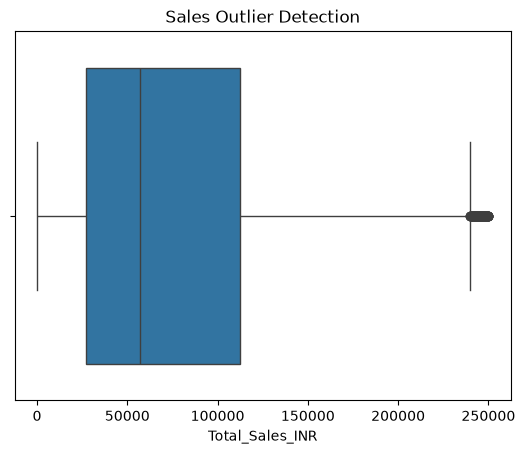

In [12]:
#Outliers check karein
sns.boxplot(x=df["Total_Sales_INR"])

plt.title("Sales Outlier Detection")
plt.show()

In [13]:
# Verify total sales calculation
df["Calculated_Sales"] = (
    df["Quantity"] * df["Unit_Price_INR"]
)

# Compare calculated sales with existing sales
mismatch = (
    df["Calculated_Sales"].round(2)
    != df["Total_Sales_INR"].round(2)
)

print("Sales mismatches:", mismatch.sum())

Sales mismatches: 0


In [ ]:
df.drop(
    columns=["Calculated_Sales"],
    inplace=True
)  #remove the temporary column after verification

In [ ]:
df.columns  

Index(['Order_ID', 'Date', 'Customer_ID', 'Product_Category', 'Product_Name',
       'Quantity', 'Unit_Price_INR', 'Total_Sales_INR', 'Payment_Method',
       'Delivery_Status', 'Review_Rating', 'Review_Text', 'State', 'Country'],
      dtype='str')

In [14]:
df["Quantity"].value_counts()

Quantity
1    3114
5    2990
4    2985
2    2967
3    2944
Name: count, dtype: int64

In [15]:
sns.set_style("whitegrid")

In [16]:
#Step 1: Total Revenue Calculate Karna
total_revenue = df["Total_Sales_INR"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 1118161803.5


In [17]:
average_sales = df["Total_Sales_INR"].mean()

print("Average Sales:", average_sales)

Average Sales: 74544.12023333333


In [18]:
#Step 2: Top 10 Products Identify Karna
top_products = (
    df.groupby("Product_Name")["Total_Sales_INR"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product_Name
Lipstick           48159020.15
Children's Book    48145664.52
Headphones         48044405.75
Hair Dryer         47428844.81
Perfume            46284732.62
Laptop             46173868.15
Tablet             46170022.15
Sneakers           46057295.93
Air Fryer          45919707.91
Jeans              45232819.47
Name: Total_Sales_INR, dtype: float64


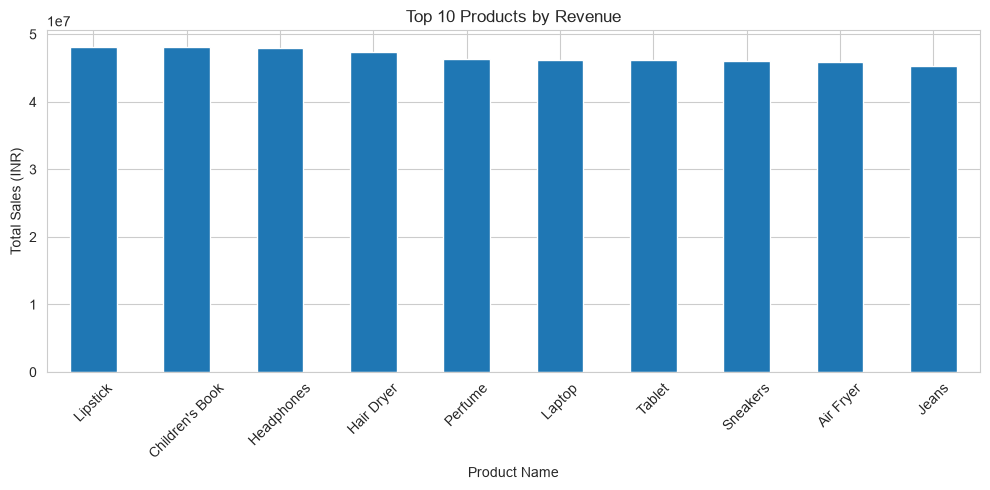

In [19]:
#Visualization
top_products.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Sales (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
#Step 2: Total Revenue by Product Category
revenue_by_category = df.groupby("Product_Category")["Total_Sales_INR"].sum().sort_values(ascending=False)
print(revenue_by_category)

Product_Category
Beauty            2.274896e+08
Electronics       2.265649e+08
Books             2.249992e+08
Clothing          2.224093e+08
Home & Kitchen    2.166987e+08
Name: Total_Sales_INR, dtype: float64


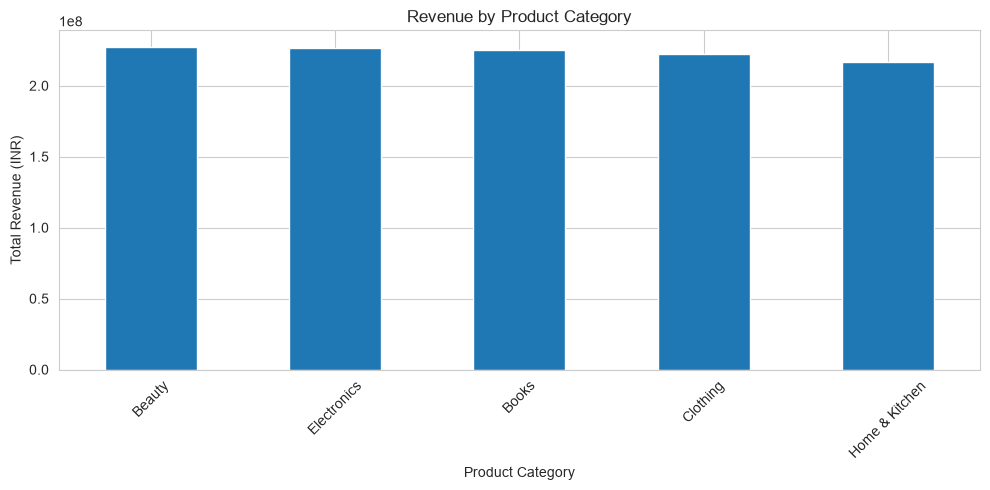

In [31]:
revenue_by_category.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
#Step 3: State-wise Sales Analysis
state_sales = (
    df.groupby("State")["Total_Sales_INR"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales.head(10))

State
Sikkim           43113469.51
Rajasthan        42906175.08
Chhattisgarh     42857545.27
Meghalaya        42773152.96
Tamil Nadu       41967968.99
Uttar Pradesh    41690917.07
Bihar            41669240.44
West Bengal      41195932.45
Tripura          41103376.81
Odisha           40924381.38
Name: Total_Sales_INR, dtype: float64


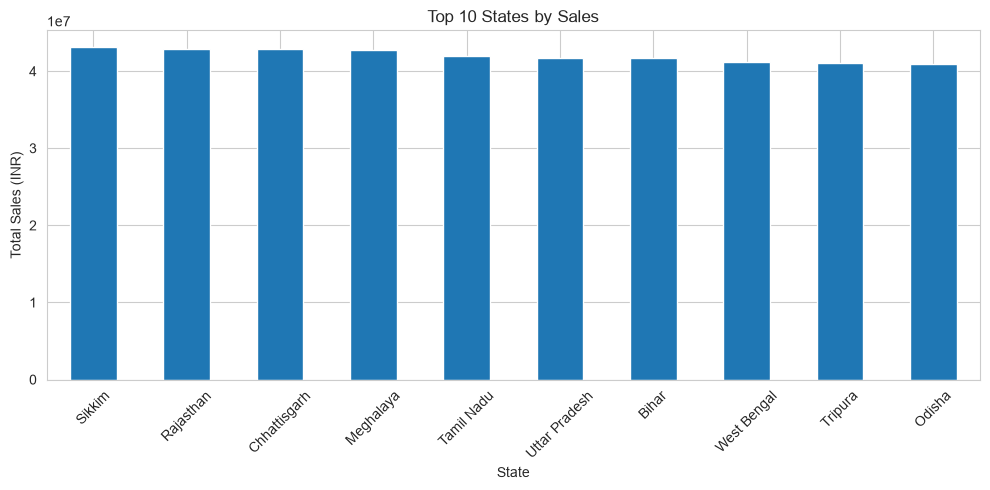

In [22]:
state_sales.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
#Step 4: Monthly Sales Trend
#conver date into datetime
df["Date"] = pd.to_datetime(df["Date"],dayfirst = True,errors="coerce")

# Calculate monthly sales
monthly_sales = (df.groupby(df["Date"].dt.month)["Total_Sales_INR"].sum().sort_index())
print(monthly_sales)

Date
1     92051785.03
2     84995760.62
3     93064349.39
4     91388990.14
5     97195848.48
6     89730685.72
7     95176904.42
8     97576563.09
9     91225555.74
10    93478344.05
11    94809186.29
12    97467830.53
Name: Total_Sales_INR, dtype: float64


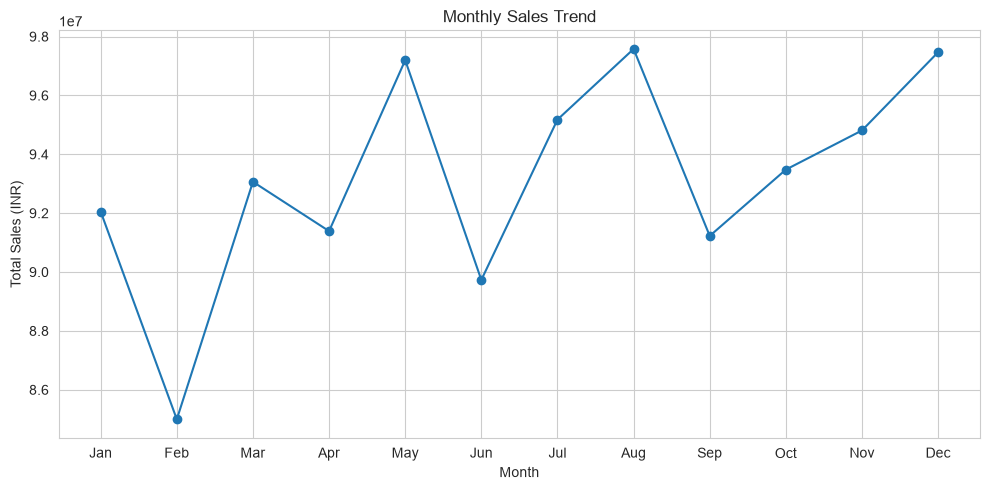

In [ ]:
##line chart for monthly sales trend
monthly_sales = (
    df.groupby(df["Date"].dt.month)["Total_Sales_INR"]
    .sum()
    .sort_index()
)

months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.xticks(range(1, 13), months)
plt.xlabel("Month")
plt.ylabel("Total Sales (INR)")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
#Step 5: Payment Method Analysis
#Business question: Customers kaun sa payment method kitni baar use karte hain?
payment_count = df["Payment_Method"].value_counts()
print(payment_count)


Payment_Method
Cash on Delivery    3827
Credit Card         3800
Debit Card          3727
UPI                 3646
Name: count, dtype: int64


In [26]:
#Pie chart for payment method distribution


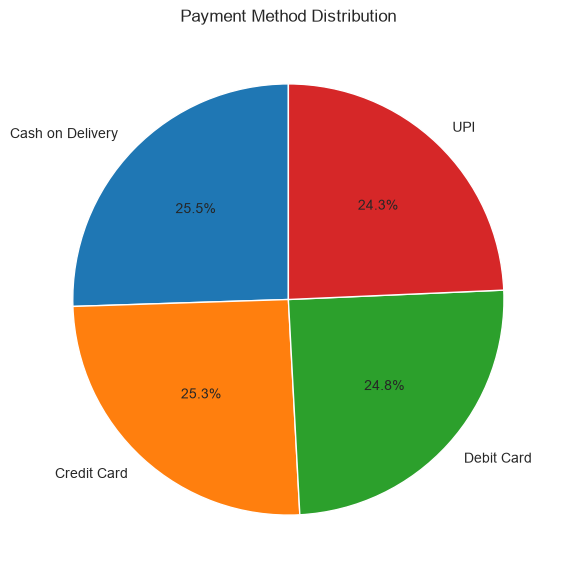

In [27]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_count,
    labels=payment_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.show()

In [28]:
#Step 6: Customer Ratings Analysis
rating_counts = df["Review_Rating"].value_counts().sort_index()
print(rating_counts)

Review_Rating
1    2839
2    2998
3    3013
4    3022
5    3128
Name: count, dtype: int64


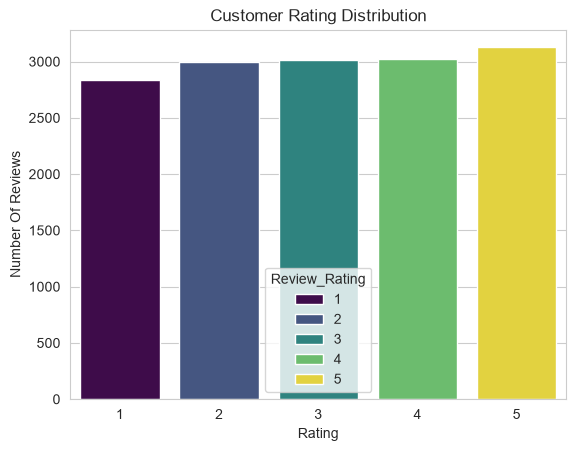

In [ ]:
#visualization of customer ratings
sns.countplot(x="Review_Rating", data=df,hue="Review_Rating",palette="viridis") #legend=False =legend=False unnecessary legend ko hide karta hai.
plt.title("Customer Rating Distribution")                                       #palette different ratings ke liye colors set karta hai.
plt.xlabel("Rating")
plt.ylabel("Number Of Reviews")
plt.show()

In [43]:
#Phase 5: Business Insights & Recommendations
#Step 1: Category-wise sales analysis
category_sales = df.groupby("Product_Category")["Total_Sales_INR"].sum().sort_values(ascending=False)
print(category_sales)

Product_Category
Beauty            2.274896e+08
Electronics       2.265649e+08
Books             2.249992e+08
Clothing          2.224093e+08
Home & Kitchen    2.166987e+08
Name: Total_Sales_INR, dtype: float64


In [44]:
#Step 2: Delivery status analysis
delivery_analysis = df["Delivery_Status"].value_counts()

print(delivery_analysis)

Delivery_Status
Delivered    5075
Pending      5044
Returned     4881
Name: count, dtype: int64


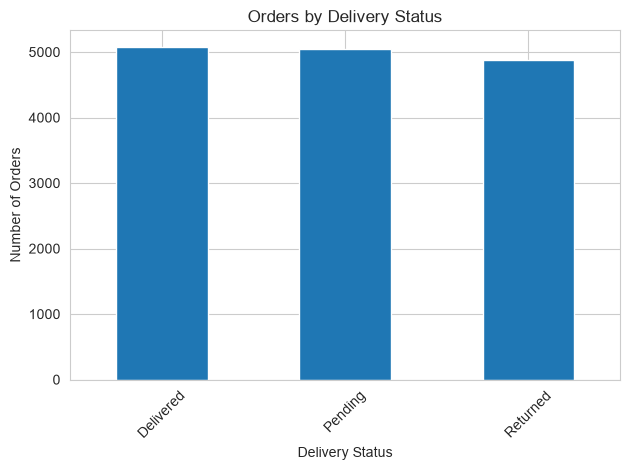

In [45]:
import matplotlib.pyplot as plt

delivery_analysis.plot(
    kind="bar",
    title="Orders by Delivery Status",
    xlabel="Delivery Status",
    ylabel="Number of Orders"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
#Step 3: Customer rating analysis
rating_analysis = df.groupby("Product_Category")["Review_Rating"].mean()

print(rating_analysis.sort_values(ascending=False))

Product_Category
Electronics       3.071146
Home & Kitchen    3.064261
Beauty            3.036703
Books             3.031960
Clothing          2.997353
Name: Review_Rating, dtype: float64


In [ ]:
#Step 4: Business recommendations
#Analysis

	

#Possible recommendation

#High-revenue category

	

#Is category ke popular products ka stock monitor karein.

#Low-revenue category

	

#Pricing, demand aur product visibility investigate karein.

#Low customer ratings

	

#Negative reviews ko analyze karke common issues identify karein.

#Pending deliveries

	

#Delayed orders ke reasons investigate karein

In [49]:
#Top-Selling Product
top_products = (
    df.groupby("Product_Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(top_products.head(10))

Product_Name
Perfume            1887
Children's Book    1881
Headphones         1880
Lipstick           1871
Hair Dryer         1839
Laptop             1834
Air Fryer          1829
Sneakers           1824
Smartwatch         1822
Jeans              1808
Name: Quantity, dtype: int64


In [ ]:
#1. Overall Average Customer Rating
# Calculate average customer rating
avg_rating = df["Review_Rating"].mean()

print("Average Customer Rating:", round(avg_rating, 2))

Average Customer Rating: 3.04


In [51]:
#2. Category-wise Average Customer Rating
# Calculate average rating for each category
category_rating = df.groupby("Product_Category")["Review_Rating"].mean()

print(category_rating.round(2))

Product_Category
Beauty            3.04
Books             3.03
Clothing          3.00
Electronics       3.07
Home & Kitchen    3.06
Name: Review_Rating, dtype: float64


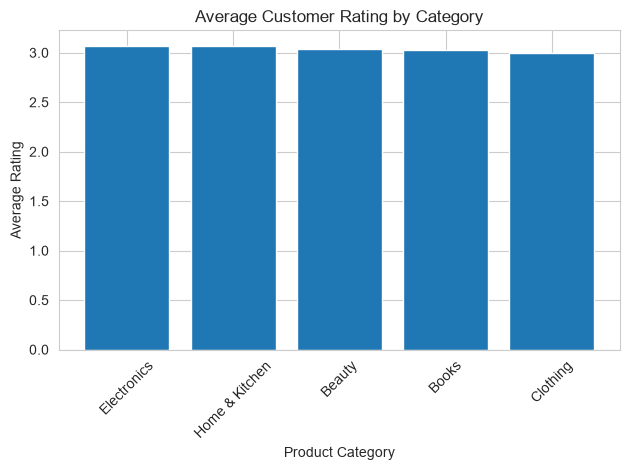

In [52]:
#3. Visualization
category_rating = category_rating.sort_values(ascending=False)

plt.bar(category_rating.index, category_rating.values)

plt.title("Average Customer Rating by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()